In [22]:
import ast
import os
import re
import dotenv
from pathlib import Path
from typing import List, Tuple, Dict, Set, Optional
from collections import defaultdict
from itertools import groupby
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import torch
import seaborn as sns
from tqdm import tqdm
from sklearn import preprocessing
import yaml
import matplotlib.gridspec as gridspec

In [23]:
#GET NECESSARY .ENV VARIABLES
dotenv.load_dotenv('../../.env')
SWEEP_EXP_DIR=os.getenv("SWEEP_EXP_DIR")
SWEEP_ANALYSIS_DIR=os.getenv("SWEEP_ANALYSIS_DIR")

In [29]:
def load_config(config_path):
    with open(config_path, 'r') as file:
        config = yaml.safe_load(file)
    return config

mappings = load_config("../../datasets/final/hierarchical_label_set.yaml")
ordered_labels_level1 = mappings["level1"]
ordered_labels_level2 = mappings["level2"]
ordered_labels_level3 = mappings["level3"]
orders = [ordered_labels_level1, ordered_labels_level2, ordered_labels_level3]

In [25]:
def get_best_model_path(train_set="hpa_uniprot_combined_trainset", level=1):
    avg_metrics = pd.read_csv(f"{SWEEP_ANALYSIS_DIR}/overall_metrics.csv")

    #DROP DUPLICATE RUNS
    idx = avg_metrics.groupby(
        ["exp_name",
        "category_level",
        "metadata_file",
        "clip_len",
        "agg_method",
        "mlp_dropout",
        "loss"
        ])["macro_ap"].idxmax()
    avg_metrics = avg_metrics.loc[idx].reset_index(drop=True)


    #GET BEST MODEL
    best_model = avg_metrics.iloc[avg_metrics[
        (avg_metrics.metadata_file == train_set)  &
        (avg_metrics.category_level == f"level{level}")
    ].macro_ap.idxmax()]

    run_id = best_model.run_id
    plm = best_model.exp_name

    #PATH TO RUN WITH BEST MODEL
    path_to_best_model = f"{SWEEP_EXP_DIR}/{plm}_hpa_uniprot_combined_trainset/{run_id}"

    return path_to_best_model, best_model

PATH_TO_BEST_MODEL, best_model = get_best_model_path()

In [16]:
hou_df = pd.read_csv("../../datasets/intermediate/motif/hou_with_peak_positions.csv")
prosite_motifs_df = pd.read_csv("../../datasets/intermediate/motif/hou_prosite_motifs.csv")
prosite_path = "../../datasets/raw/prosite.dat"
sorting_singal_path = "../../datasets/intermediate/motif/hou_sorting_singals.csv"
FIG_DIR = "../../figures/motif"

In [17]:
if not os.path.exists(sorting_singal_path):
    sortings_sigs = pd.read_pickle("../../Benchmark-Models/DeepLoc2/data_files/multisub_ninesignals.pkl")
    hou = pd.read_csv("../../datasets/final/hou_testset.csv")
    compartment_cols = [
        "Membrane", "Cytoplasm", "Nucleus", "Extracellular", "Cell membrane",
        "Mitochondrion", "Plastid", "Endoplasmic reticulum",
        "Lysosome/Vacuole", "Golgi apparatus", "Peroxisome"
    ]
    sortings_sigs["Compartments"] = sortings_sigs[compartment_cols].apply(
        lambda row: ";".join([col for col in compartment_cols if row[col] == 1]), axis=1)
    sortings_sigs = sortings_sigs.drop(compartment_cols, axis=1).rename({"Sequence": "sequence"}, axis=1)
    df = sortings_sigs.merge(hou, how="inner", left_on="ACC", right_on="uniprot_id", suffixes=["_dl2", "_hou"])
    df = df[df.sequence_hou == df.sequence_dl2].reset_index(drop=True)
    df = df.drop(["Kingdom", "Partition", "sequence_dl2"], axis=1)

    sig_dict = {1.0:"SP", 2.0:"TM", 3.0:"MT", 6.0:"NLS", 7.0:"NES", 8.0:"PTS", 9.0:"GPI"}

    def get_signal_ranges(s):
        ranges, start, end = [], 0, 0
        for i, group in groupby(s):
            length = len(list(group))
            end = start+length-1
            if i != 0:
                ranges.append((start, end))
            start = end+1
        return ranges

    def get_signal_type(s):
        return [i for i, group in groupby(s) if i != 0]

    df["range"] = df.ANNOT.apply(get_signal_ranges)
    df["signal_type"] = df.ANNOT.apply(get_signal_type).apply(lambda l: [sig_dict[i] for i in l])

    rows = [
        {
            "uniprot_id": row["uniprot_id"],
            "signal_id": f'{row["uniprot_id"]}_{n}',
            "start_pos": row["range"][n][0],
            "end_pos": row["range"][n][1],
            "signal_type": row["signal_type"][n]
        }
        for _, row in df.iterrows()
        for n in range(len(row["signal_type"]))
    ]
    df = pd.DataFrame(rows)
    df.to_csv(sorting_singal_path, index=False)

In [20]:
def merge_overlapping_peaks(peaks_list):
    if not peaks_list:
        return []
    
    # Sort peaks by start position
    peaks_list = sorted(peaks_list, key=lambda x: x[0])
    
    merged_peaks = [peaks_list[0]]
    for current in peaks_list[1:]:
        previous = merged_peaks[-1]
        # If current peak overlaps with previous peak
        if current[0] <= previous[1]:
            # Merge by updating the end position of previous peak
            merged_peaks[-1][1] = max(previous[1], current[1])
        else:
            # Add current peak to the result if no overlap
            merged_peaks.append(current)
    
    return merged_peaks

# Create empty lists to hold the data
peak_uniprot_ids = []
peak_ids = []
peak_start_pos = []
peak_end_pos = []
peak_length = []

for i, row in hou_df.iterrows():
    uniprot_id = row['uniprot_id']
    # Convert string representation to actual list if needed
    if isinstance(row['peak_positions'], str):
        peaks = ast.literal_eval(row['peak_positions'])
    else:
        peaks = row['peak_positions']
    
    # Merge overlapping peaks
    merged_peaks = merge_overlapping_peaks(peaks)
    
    # Add each peak to the lists
    for j, peak in enumerate(merged_peaks):
        peak_uniprot_ids.append(uniprot_id)
        peak_ids.append(f"{uniprot_id}_peak_{j}")
        peak_start_pos.append(peak[0])
        peak_end_pos.append(peak[1])
        peak_length.append(peak[1] - peak[0])

# Create the peaks dataframe
peaks_df = pd.DataFrame({
    "uniprot_id": peak_uniprot_ids,
    "peak_id": peak_ids,
    "start_pos": peak_start_pos,
    "end_pos": peak_end_pos,
    "length": peak_length
})

print(f"Created peaks dataframe with {len(peaks_df)} rows")
peaks_df.head()

# Task 2: Correct start/end positions for Prosite motifs based on sequence truncation
def correct_position(start_pos, end_pos, seq_length):
    # If sequence <= 1024, no correction needed
    if seq_length <= 1024:
        return start_pos, end_pos, True
    
    # For sequences > 1024, check if the motif is within first 512 or last 512 residues
    if start_pos < 512:
        # Motif in first 512 residues
        return start_pos, end_pos, True
    elif start_pos >= seq_length - 512:
        # Motif in last 512 residues
        # Adjust position: new_pos = (pos - (seq_length - 512)) + 512
        corrected_start = (start_pos - (seq_length - 512)) + 512
        corrected_end = (end_pos - (seq_length - 512)) + 512
        return corrected_start, corrected_end, True
    else:
        # Motif falls in the middle region that was cut out
        return None, None, False

# Create a mapping of uniprot_id to sequence length
seq_length_map = dict(zip(hou_df['uniprot_id'], hou_df['sequence'].apply(len)))

# Apply the correction to prosite_motifs_df
corrected_start = []
corrected_end = []
valid_motifs = []

for i, row in prosite_motifs_df.iterrows():
    uniprot_id = row['protein_id']
    start_pos = row['start_pos']
    end_pos = row['end_pos']
    
    # Get sequence length for this protein
    seq_length = seq_length_map.get(uniprot_id)
    
    if seq_length:
        c_start, c_end, is_valid = correct_position(start_pos, end_pos, seq_length)
        corrected_start.append(c_start)
        corrected_end.append(c_end)
        valid_motifs.append(is_valid)
    else:
        # If protein not found in hou_df, mark as invalid
        corrected_start.append(None)
        corrected_end.append(None)
        valid_motifs.append(False)

# Add new columns to prosite_motifs_df
prosite_motifs_df['corrected_start_pos'] = corrected_start
prosite_motifs_df['corrected_end_pos'] = corrected_end
prosite_motifs_df['valid_motif'] = valid_motifs

# Filter out invalid motifs
corrected_prosite_motifs_df = prosite_motifs_df[prosite_motifs_df['valid_motif']].copy()
corrected_prosite_motifs_df.drop('valid_motif', axis=1, inplace=True)

print(f"Original prosite motifs count: {len(prosite_motifs_df)}")
print(f"Corrected prosite motifs count: {len(corrected_prosite_motifs_df)}")
corrected_prosite_motifs_df.head()

Created peaks dataframe with 8943 rows
Original prosite motifs count: 7471
Corrected prosite motifs count: 6755


,protein_id,motif_ac,start_pos,end_pos,score,length,corrected_start_pos,corrected_end_pos
0,A0A087X0K9,PS50106,23,110,0.0,88,23.0,110.0
1,A0A087X0K9,PS50106,186,264,0.0,79,186.0,264.0
2,A0A087X0K9,PS50106,421,502,0.0,82,421.0,502.0
5,A0A087X0K9,PS51145,1634,1768,0.0,135,890.0,1024.0
6,A0A1B0GTU4,PS50023,846,905,0.0,60,789.0,848.0


In [30]:
# Function to parse PROSITE database for motif classifications (from enhanced_motif_analysis.py)
def parse_prosite_dat(prosite_path):
    """
    Parse the PROSITE database file to extract motif classifications.
    
    Args:
        prosite_path: Path to the prosite.dat file
        
    Returns:
        Dictionary mapping motif accession (AC) to a dictionary of properties
    """
    motif_data = {}
    current_ac = None
    current_data = {}
    
    # Pattern for ID line: ID   ASN_GLYCOSYLATION; PATTERN.
    id_pattern = re.compile(r'ID\s+([^;]+);\s+([^.]+)\.')
    
    # Pattern for AC line: AC   PS00001;
    ac_pattern = re.compile(r'AC\s+(PS\d+);')
    
    # Pattern for DE line: DE   N-glycosylation site.
    de_pattern = re.compile(r'DE\s+(.+)\.')
    
    # Categories based on description
    category_keywords = {
        'phosphorylation': ['phospho', 'kinase'],
        'glycosylation': ['glyco'],
        'binding': ['binding', 'domain', 'motif'],
        'localization': ['local', 'target', 'signal', 'export', 'import', 'retention'],
        'proteolytic': ['cleav', 'protease', 'peptidase'],
        'structural': ['struct', 'fold', 'helix', 'sheet', 'coil'],
        'catalytic': ['catalytic', 'active site', 'enzyme'],
        'dna_binding': ['dna', 'zinc finger', 'leucine zipper', 'helix-turn-helix', 'homeodomain'],
        'metal_binding': ['metal', 'zinc', 'iron', 'calcium', 'copper', 'magnesium'],
        'lipid': ['lipid', 'myristoyl', 'prenyl', 'GPI']
    }
    
    with open(prosite_path, 'r') as f:
        for line in f:
            line = line.strip()
            
            # Skip comment and empty lines
            if line.startswith('CC') or line.startswith('//') or not line:
                continue
                
            # ID line (contains motif name and type)
            id_match = id_pattern.match(line)
            if id_match:
                if current_ac and current_data:
                    motif_data[current_ac] = current_data
                current_data = {
                    'name': id_match.group(1).strip(),
                    'type': id_match.group(2).strip()
                }
                continue
                
            # AC line (contains accession number)
            ac_match = ac_pattern.match(line)
            if ac_match:
                current_ac = ac_match.group(1).strip()
                continue
                
            # DE line (contains description)
            de_match = de_pattern.match(line)
            if de_match:
                description = de_match.group(1).strip()
                current_data['description'] = description
                
                # Determine category based on description
                category = 'other'
                desc_lower = description.lower()
                for cat, keywords in category_keywords.items():
                    if any(kw.lower() in desc_lower for kw in keywords):
                        category = cat
                        break
                current_data['category'] = category
                continue
    
    # Add the last entry
    if current_ac and current_data:
        motif_data[current_ac] = current_data
        
    return motif_data

# Function to add motif categories to dataframe
def add_motif_categories_to_df(motif_df, motif_data):
    """Add motif classification data to a dataframe containing motif information."""
    # Create new columns
    motif_df['motif_name'] = motif_df['motif_ac'].apply(
        lambda ac: motif_data.get(ac, {}).get('name', 'Unknown'))
    motif_df['motif_description'] = motif_df['motif_ac'].apply(
        lambda ac: motif_data.get(ac, {}).get('description', 'Unknown'))
    motif_df['motif_type'] = motif_df['motif_ac'].apply(
        lambda ac: motif_data.get(ac, {}).get('type', 'Unknown'))
    motif_df['motif_category'] = motif_df['motif_ac'].apply(
        lambda ac: motif_data.get(ac, {}).get('category', 'other'))
    
    return motif_df

# Function to calculate overlap percentage
def calculate_overlap_percentage(a, b):
    """
    Calculate what percentage of interval a overlaps with interval b.
    Returns value between 0.0 (no overlap) and 1.0 (complete overlap).
    """
    # No overlap
    if a[1] < b[0] or b[1] < a[0]:
        return 0.0
    
    # Calculate overlap
    overlap_start = max(a[0], b[0])
    overlap_end = min(a[1], b[1])
    overlap_length = overlap_end - overlap_start + 1
    
    # Calculate percentage of a that overlaps with b
    a_length = a[1] - a[0] + 1
    return overlap_length / a_length

# Function to check if a motif overlaps with any peak by at least 50%
def motif_overlaps_any_peak(motif_start, motif_end, peak_df, min_overlap_pct=0.5):
    """Check if a motif overlaps with any peak by at least min_overlap_pct."""
    for _, peak in peak_df.iterrows():
        peak_start = peak['start_pos']
        peak_end = peak['end_pos']
        if calculate_overlap_percentage((motif_start, motif_end), (peak_start, peak_end)) >= min_overlap_pct:
            return True
    return False

# Function to get color for motif category
def get_motif_category_color(category):
    """Return a color for each motif category."""
    color_map = {
        'phosphorylation': 'royalblue',
        'glycosylation': 'forestgreen',
        'binding': 'darkorange',
        'localization': 'purple',
        'proteolytic': 'crimson',
        'structural': 'teal',
        'catalytic': 'goldenrod',
        'dna_binding': 'darkred',
        'metal_binding': 'darkgreen',
        'lipid': 'navy',
        'other': 'gray'
    }
    return color_map.get(category, 'gray')

# Function to get color for sorting signal type
def get_signal_type_color(signal_type):
    """Return a color for each sorting signal type."""
    color_map = {
        'SP': 'royalblue',     # Signal Peptide
        'MT': 'forestgreen',   # Mitochondrial Targeting
        'NLS': 'darkorange',   # Nuclear Localization Signal
        'NES': 'purple',       # Nuclear Export Signal
        'TM': 'crimson',       # Transmembrane
        'PTS': 'teal',         # Peroxisomal Targeting Signal
        'ER': 'goldenrod',     # ER Retention
        'KDEL': 'darkred',     # KDEL ER retention motif
        'Other': 'gray'
    }
    return color_map.get(signal_type, 'gray')

# Function to plot overlap heatmap
def plot_overlap_heatmap(overlap_df, title, filename, cmap="YlOrRd"):
    """Plot heatmap of overlap percentages."""
    plt.figure(figsize=(12, 10))
    ax = sns.heatmap(overlap_df, annot=True, fmt=".1f", cmap=cmap, vmin=0, vmax=100)
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()

# Function to plot stacked bar chart
def plot_stacked_bar(class_stats, categories, category_colors, title, xlabel, filename):
    """Plot stacked bar chart of overlap percentages by category."""
    plt.figure(figsize=(14, 10))
    
    # Get classes and sort them by total overlap percentage
    classes = class_stats["class"].tolist()
    
    # Create stacked bars
    previous_heights = np.zeros(len(classes))
    
    for cat in categories:
        # Calculate what percentage of total this category represents for each class
        category_pcts = []
        for cls_idx, cls in enumerate(classes):
            row = class_stats.iloc[cls_idx]
            total_items = row["total_items"]
            category_items = row[f"{cat}_items"]
            category_overlap = row[f"{cat}_overlapping"]
            
            # Calculate percentage of this category that overlaps
            if category_items > 0:
                pct = (category_overlap / total_items * 100) if total_items > 0 else 0
                category_pcts.append(pct)
            else:
                category_pcts.append(0)
        
        # Create this category's bars
        plt.barh(
            np.arange(len(classes)), 
            category_pcts,
            left=previous_heights, 
            label=cat,
            color=category_colors.get(cat, 'gray')
        )
        
        # Update previous heights for next category
        previous_heights += category_pcts
    
    # Add total values as text at the end of each bar
    for i, cls in enumerate(classes):
        plt.text(
            previous_heights[i] + 0.5,
            i,
            f"{class_stats.iloc[i]['overlap_pct']:.1f}%",
            va='center',
            fontsize=8
        )
    
    plt.yticks(np.arange(len(classes)), classes)
    plt.xlabel(xlabel)
    plt.title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.legend(loc='lower right', bbox_to_anchor=(1.1, 0))
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()

# Parse prosite database for motif classifications
print("Parsing PROSITE database...")
motif_data = parse_prosite_dat(prosite_path)
print(f"Parsed {len(motif_data)} motifs from PROSITE database")

# Add motif categories to the corrected_prosite_motifs_df
corrected_prosite_motifs_df = add_motif_categories_to_df(corrected_prosite_motifs_df, motif_data)

# Create output directory if it doesn't exist
os.makedirs(FIG_DIR, exist_ok=True)

# Get all unique motif categories
motif_categories = corrected_prosite_motifs_df['motif_category'].dropna().unique().tolist()
if 'other' in motif_categories:
    motif_categories.remove('other')
    motif_categories.append('other')  # Move 'other' to the end

# Get all unique sorting signal types
signal_types = sorted(sorting_sigs_df['signal_type'].unique().tolist())

# Dictionary to store motif category colors
motif_category_colors = {cat: get_motif_category_color(cat) for cat in motif_categories}

# Dictionary to store signal type colors
signal_type_colors = {sig: get_signal_type_color(sig) for sig in signal_types}

# Process each level of localization classes
for level in [1, 2, 3]:
    level_classes = orders[level-1]
    print(f"\nProcessing level {level} with {len(level_classes)} classes")
    
    # =====================================================================
    # Part 1: Analyze Prosite Motifs overlap with peaks by localization class
    # =====================================================================
    
    # Initialize data structures for motif analysis
    class_motifs = {cls: 0 for cls in level_classes}
    class_overlapping_motifs = {cls: 0 for cls in level_classes}
    class_motif_category_counts = {
        cls: {cat: 0 for cat in motif_categories} for cls in level_classes
    }
    class_motif_category_overlap_counts = {
        cls: {cat: 0 for cat in motif_categories} for cls in level_classes
    }
    
    # Process each protein
    for _, row in hou_df.iterrows():
        protein_id = row['uniprot_id']
        level_class = row[f'level{level}']
        
        # Skip if level_class is not in our list
        if level_class not in level_classes:
            continue
        
        # Get motifs for this protein
        protein_motifs = corrected_prosite_motifs_df[corrected_prosite_motifs_df['protein_id'] == protein_id]
        
        # Skip if no motifs found
        if len(protein_motifs) == 0:
            continue
        
        # Get peaks for this protein
        protein_peaks = peaks_df[peaks_df['uniprot_id'] == protein_id]
        
        # Update total motif count for this class
        class_motifs[level_class] += len(protein_motifs)
        
        # Process each motif
        for _, motif in protein_motifs.iterrows():
            motif_category = motif.get('motif_category', 'other')
            start_pos = motif['corrected_start_pos']
            end_pos = motif['corrected_end_pos']
            
            # Update category count
            class_motif_category_counts[level_class][motif_category] += 1
            
            # Check if this motif overlaps with any peak by >50%
            if motif_overlaps_any_peak(start_pos, end_pos, protein_peaks):
                class_overlapping_motifs[level_class] += 1
                class_motif_category_overlap_counts[level_class][motif_category] += 1
    
    # Calculate percentages and create dataframe for visualization
    motif_stats_data = []
    for cls in level_classes:
        total_motifs = class_motifs[cls]
        overlapping_motifs = class_overlapping_motifs[cls]
        overlap_pct = (overlapping_motifs / total_motifs * 100) if total_motifs > 0 else 0
        
        cls_data = {
            "class": cls,
            "total_items": total_motifs,
            "overlapping_items": overlapping_motifs,
            "overlap_pct": overlap_pct
        }
        
        # Add per-category counts and overlaps
        for cat in motif_categories:
            cat_count = class_motif_category_counts[cls][cat]
            cat_overlap = class_motif_category_overlap_counts[cls][cat]
            cat_pct = (cat_overlap / cat_count * 100) if cat_count > 0 else 0
            
            cls_data[f"{cat}_items"] = cat_count
            cls_data[f"{cat}_overlapping"] = cat_overlap
            cls_data[f"{cat}_pct"] = cat_pct
        
        motif_stats_data.append(cls_data)
    
    # Create dataframe
    motif_stats_df = pd.DataFrame(motif_stats_data)
    motif_stats_df = motif_stats_df.sort_values('overlap_pct', ascending=False)
    
    # Create heatmap data
    heatmap_data = np.zeros((len(level_classes), len(motif_categories)))
    for i, cls in enumerate(motif_stats_df['class']):
        for j, cat in enumerate(motif_categories):
            cat_pct = motif_stats_df.iloc[i][f"{cat}_pct"]
            heatmap_data[i, j] = cat_pct
    
    # Create heatmap DataFrame
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=motif_stats_df['class'],
        columns=motif_categories
    )
    
    # Plot motif overlap heatmap
    plot_overlap_heatmap(
        heatmap_df, 
        f"Prosite Motif-Peak Overlap by Class and Motif Category (Level {level})", 
        os.path.join(FIG_DIR, f"motif_peak_overlap_heatmap_level{level}.svg")
    )
    
    # Plot motif stacked bar chart
    plot_stacked_bar(
        motif_stats_df,
        motif_categories,
        motif_category_colors,
        f"Proportion of Motifs that Overlap with Attention Peaks by Motif Category (Level {level})",
        'Percentage of Motifs Overlapping with Attention Peaks (>50% overlap)',
        os.path.join(FIG_DIR, f"motif_peak_overlap_stackedbar_level{level}.svg")
    )
    
    # Save motif statistics
    motif_stats_df.to_csv(os.path.join(FIG_DIR, f"motif_peak_overlap_stats_level{level}.csv"), index=False)
    
    # =====================================================================
    # Part 2: Analyze Sorting Signals overlap with peaks by localization class
    # =====================================================================
    
    # Initialize data structures for sorting signal analysis
    class_signals = {cls: 0 for cls in level_classes}
    class_overlapping_signals = {cls: 0 for cls in level_classes}
    class_signal_type_counts = {
        cls: {sig: 0 for sig in signal_types} for cls in level_classes
    }
    class_signal_type_overlap_counts = {
        cls: {sig: 0 for sig in signal_types} for cls in level_classes
    }
    
    # Process each protein
    for _, row in hou_df.iterrows():
        protein_id = row['uniprot_id']
        level_class = row[f'level{level}']
        
        # Skip if level_class is not in our list
        if level_class not in level_classes:
            continue
        
        # Get sorting signals for this protein
        protein_signals = sorting_sigs_df[sorting_sigs_df['uniprot_id'] == protein_id]
        
        # Skip if no signals found
        if len(protein_signals) == 0:
            continue
        
        # Get peaks for this protein
        protein_peaks = peaks_df[peaks_df['uniprot_id'] == protein_id]
        
        # Update total signal count for this class
        class_signals[level_class] += len(protein_signals)
        
        # Process each signal
        for _, signal in protein_signals.iterrows():
            signal_type = signal['signal_type']
            start_pos = signal['start_pos']
            end_pos = signal['end_pos']
            
            # Update type count
            class_signal_type_counts[level_class][signal_type] += 1
            
            # Check if this signal overlaps with any peak by >50%
            if motif_overlaps_any_peak(start_pos, end_pos, protein_peaks):
                class_overlapping_signals[level_class] += 1
                class_signal_type_overlap_counts[level_class][signal_type] += 1
    
    # Calculate percentages and create dataframe for visualization
    signal_stats_data = []
    for cls in level_classes:
        total_signals = class_signals[cls]
        overlapping_signals = class_overlapping_signals[cls]
        overlap_pct = (overlapping_signals / total_signals * 100) if total_signals > 0 else 0
        
        cls_data = {
            "class": cls,
            "total_items": total_signals,
            "overlapping_items": overlapping_signals,
            "overlap_pct": overlap_pct
        }
        
        # Add per-type counts and overlaps
        for sig_type in signal_types:
            type_count = class_signal_type_counts[cls][sig_type]
            type_overlap = class_signal_type_overlap_counts[cls][sig_type]
            type_pct = (type_overlap / type_count * 100) if type_count > 0 else 0
            
            cls_data[f"{sig_type}_items"] = type_count
            cls_data[f"{sig_type}_overlapping"] = type_overlap
            cls_data[f"{sig_type}_pct"] = type_pct
        
        signal_stats_data.append(cls_data)
    
    # Create dataframe
    signal_stats_df = pd.DataFrame(signal_stats_data)
    signal_stats_df = signal_stats_df.sort_values('overlap_pct', ascending=False)
    
    # Create heatmap data
    heatmap_data = np.zeros((len(level_classes), len(signal_types)))
    for i, cls in enumerate(signal_stats_df['class']):
        for j, sig_type in enumerate(signal_types):
            type_pct = signal_stats_df.iloc[i][f"{sig_type}_pct"]
            heatmap_data[i, j] = type_pct
    
    # Create heatmap DataFrame
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=signal_stats_df['class'],
        columns=signal_types
    )
    
    # Plot signal overlap heatmap
    plot_overlap_heatmap(
        heatmap_df, 
        f"Sorting Signal-Peak Overlap by Class and Signal Type (Level {level})", 
        os.path.join(FIG_DIR, f"signal_peak_overlap_heatmap_level{level}.svg")
    )
    
    # Plot signal stacked bar chart
    plot_stacked_bar(
        signal_stats_df,
        signal_types,
        signal_type_colors,
        f"Proportion of Sorting Signals that Overlap with Attention Peaks by Signal Type (Level {level})",
        'Percentage of Sorting Signals Overlapping with Attention Peaks (>50% overlap)',
        os.path.join(FIG_DIR, f"signal_peak_overlap_stackedbar_level{level}.svg")
    )
    
    # Save signal statistics
    signal_stats_df.to_csv(os.path.join(FIG_DIR, f"signal_peak_overlap_stats_level{level}.csv"), index=False)

print(f"\nAnalysis complete. Results saved to {FIG_DIR}")

Parsing PROSITE database...
Parsed 1736 motifs from PROSITE database

Processing level 1 with 22 classes

Processing level 2 with 10 classes

Processing level 3 with 8 classes

Analysis complete. Results saved to ../../figures/motif


In [31]:
# Function for smoothing attention values using moving average
def moving_average(x, window_size=5):
    """Calculate moving average with specified window size."""
    if window_size % 2 == 0:
        window_size += 1
    half_window = window_size // 2
    if len(x) < window_size:
        return x
    smoothed = np.zeros_like(x)
    smoothed[:half_window] = x[:half_window]
    smoothed[-half_window:] = x[-half_window:]
    for i in range(half_window, len(x) - half_window):
        smoothed[i] = np.mean(x[i-half_window:i+half_window+1])
    return smoothed

# Function to rescale and smooth attention values
def rescale_att_protein(protein_seq, att_vec, window_size=7):
    """Rescale attention and apply smoothing."""
    len_prot = len(protein_seq)
    if len_prot < 1024:
        truncated_att = att_vec[:len_prot]
    else:
        truncated_att = att_vec[:1024]
    mm_att = preprocessing.MinMaxScaler().fit_transform(truncated_att.reshape(-1, 1)).flatten()
    smoothed_att = moving_average(mm_att, window_size=window_size)
    if len(smoothed_att) < 1024:
        diff_len = 1024 - len_prot
        pad_0 = np.zeros(diff_len)
        smoothed_att = np.concatenate([smoothed_att, pad_0])
    return smoothed_att

# Function to load attention data for a protein
def load_attention_data(experiment_folder, protein_id, hou_df, window_size=9):
    """Load and process attention data for a protein."""
    test_attentions = []
    for i in range(5):
        folder = f'{experiment_folder}/fold_{i}/'
        att = torch.load(f'{folder}fold_{i}_test_attention.pt')
        test_attentions.append(att)
    
    test_attentions = torch.stack(test_attentions).mean(dim=0).cpu().numpy()
    protein_idx = hou_df[hou_df["uniprot_id"] == protein_id].index[0]
    sequence = hou_df.loc[protein_idx, "sequence"]
    attention = test_attentions[protein_idx]
    smoothed_att = rescale_att_protein(sequence, attention, window_size=window_size)
    
    return smoothed_att, sequence

# Function to get model input sequence (handling truncation for long sequences)
def get_model_seq(protein_seq):
    """Get the sequence that was actually input to the model."""
    if len(protein_seq) > 1024:
        return protein_seq[:512] + protein_seq[-512:]
    return protein_seq

# Function to calculate overlap percentage
def calculate_overlap_percentage(a, b):
    """Calculate what percentage of interval a overlaps with interval b."""
    if a[1] < b[0] or b[1] < a[0]:
        return 0.0
    overlap_start = max(a[0], b[0])
    overlap_end = min(a[1], b[1])
    overlap_length = overlap_end - overlap_start + 1
    a_length = a[1] - a[0] + 1
    return overlap_length / a_length

# Function to plot a single protein with motifs, signals, and peaks
def plot_protein_with_features(ax, protein_id, sequence, motifs, signals, peaks, att_values, has_overlap=True):
    """Plot protein sequence with motifs, signals, and attention peaks."""
    # Get model input sequence (handling truncation for long sequences)
    model_seq = get_model_seq(sequence)
    seq_len = len(model_seq)
    
    # Truncate attention values to match sequence length
    att_values = att_values[:seq_len]
    
    # Plot attention profile
    x = np.arange(seq_len)
    ax.plot(x, att_values, color='black', linewidth=1.0, label='Attention')
    
    # Track label positions to avoid overlaps
    label_positions = []
    
    # Plot motifs (baby blue)
    for _, motif in motifs.iterrows():
        start = int(motif['corrected_start_pos'])
        end = int(motif['corrected_end_pos'])
        
        # Skip if out of bounds
        if start >= seq_len:
            continue
            
        # Adjust end position if it exceeds sequence length
        if end >= seq_len:
            end = seq_len - 1
            
        # Add highlight rectangle for motif
        rect = patches.Rectangle(
            (start, -0.1), end-start, 1.2,
            linewidth=0, alpha=0.7, 
            facecolor='skyblue'  # baby blue color
        )
        ax.add_patch(rect)
        
        # Add motif label
        motif_center = (start + end) / 2
        y_pos = 1.05
        text_height = 0.1
        
        # Check for label overlaps
        for pos in label_positions:
            existing_x, existing_y, existing_width = pos
            if abs(motif_center - existing_x) < (existing_width/2 + 20):
                y_pos = existing_y - text_height
                
        label = ax.text(
            motif_center, y_pos, motif['motif_ac'], 
            fontsize=7, ha='center', va='bottom', color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
        )
        
        # Estimate label width
        label_width = len(motif['motif_ac']) * 4
        label_positions.append((motif_center, y_pos, label_width))
    
    # Plot sorting signals (salmon pink)
    for _, signal in signals.iterrows():
        start = int(signal['start_pos'])
        end = int(signal['end_pos'])
        
        # Skip if out of bounds
        if start >= seq_len:
            continue
            
        # Adjust end position if it exceeds sequence length
        if end >= seq_len:
            end = seq_len - 1
            
        # Add highlight rectangle for signal
        rect = patches.Rectangle(
            (start, -0.1), end-start, 1.2,
            linewidth=0, alpha=0.5, 
            facecolor='salmon'  # salmon pink color
        )
        ax.add_patch(rect)
        
        # Add signal label
        signal_center = (start + end) / 2
        y_pos = 1.05
        text_height = 0.1
        
        # Check for label overlaps
        for pos in label_positions:
            existing_x, existing_y, existing_width = pos
            if abs(signal_center - existing_x) < (existing_width/2 + 20):
                y_pos = existing_y - text_height
                
        label = ax.text(
            signal_center, y_pos, signal['signal_type'], 
            fontsize=7, ha='center', va='bottom', color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
        )
        
        # Estimate label width
        label_width = len(signal['signal_type']) * 4
        label_positions.append((signal_center, y_pos, label_width))
    
    # Plot peaks (red brackets)
    for _, peak in peaks.iterrows():
        peak_start = peak['start_pos']
        peak_end = peak['end_pos']
        
        # Skip if out of bounds
        if peak_start >= seq_len:
            continue
            
        # Adjust end position if it exceeds sequence length
        if peak_end >= seq_len:
            peak_end = seq_len - 1
            
        # Add red bracket for peak region
        rect = patches.Rectangle(
            (peak_start, -0.2), peak_end-peak_start, 1.4, 
            linewidth=1.5, edgecolor='red', 
            facecolor='none', alpha=0.7
        )
        ax.add_patch(rect)
    
    # Set title and axis labels
    overlap_status = "With Overlap" if has_overlap else "No Overlap"
    ax.set_title(f"{protein_id} ({overlap_status})", fontsize=10)
    ax.set_xlim(-5, seq_len + 5)
    ax.set_ylim(-0.3, 1.2)
    ax.set_xlabel('Residue Position', fontsize=8)
    ax.set_ylabel('Norm. Attention', fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=6)
    
    return ax




# Function to check if a feature (motif or signal) overlaps with any peak
def check_overlap_with_peak(start_pos, end_pos, protein_peaks, min_overlap_pct=0.5):
    for _, peak in protein_peaks.iterrows():
        peak_start = peak['start_pos']
        peak_end = peak['end_pos']
        if calculate_overlap_percentage((start_pos, end_pos), (peak_start, peak_end)) >= min_overlap_pct:
            return True
    return False

Found 124 proteins with both motifs and localization signals

Proteins with at least one motif/signal overlapping with a peak:
P08138: 10 motifs, 2 signals, 2 peaks
Q03405: 3 motifs, 1 signals, 3 peaks
O60883: 1 motifs, 2 signals, 4 peaks
Q92560: 2 motifs, 1 signals, 4 peaks
P40238: 3 motifs, 2 signals, 2 peaks
Q8IZP9: 3 motifs, 2 signals, 5 peaks
Q9UM73: 6 motifs, 2 signals, 4 peaks
P37173: 3 motifs, 2 signals, 3 peaks
O00206: 13 motifs, 2 signals, 3 peaks
P49755: 1 motifs, 2 signals, 2 peaks

Proteins with no motifs/signals overlapping with any peak:
Q9NRG9: 3 motifs, 1 signals, 2 peaks
Q9UDY8: 3 motifs, 2 signals, 3 peaks
Q7RTP6: 1 motifs, 1 signals, 4 peaks
P30044: 1 motifs, 1 signals, 1 peaks
P78545: 2 motifs, 2 signals, 2 peaks
Q9UHK6: 1 motifs, 1 signals, 2 peaks
Q9H9S0: 2 motifs, 1 signals, 3 peaks
Q8NAG6: 5 motifs, 2 signals, 3 peaks
Q92833: 1 motifs, 1 signals, 3 peaks
Q9C0C9: 1 motifs, 1 signals, 4 peaks

Selected proteins with overlap:
['P08138', 'Q03405', 'O60883', 'Q92560

/tmp/ipykernel_58493/2736172604.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  att = torch.load(f'{folder}fold_{i}_test_attention.pt')
/tmp/ipykernel_58493/2736172604.

Visualization saved to: ../../figures/motif/protein_features_comparison_20proteins.svg


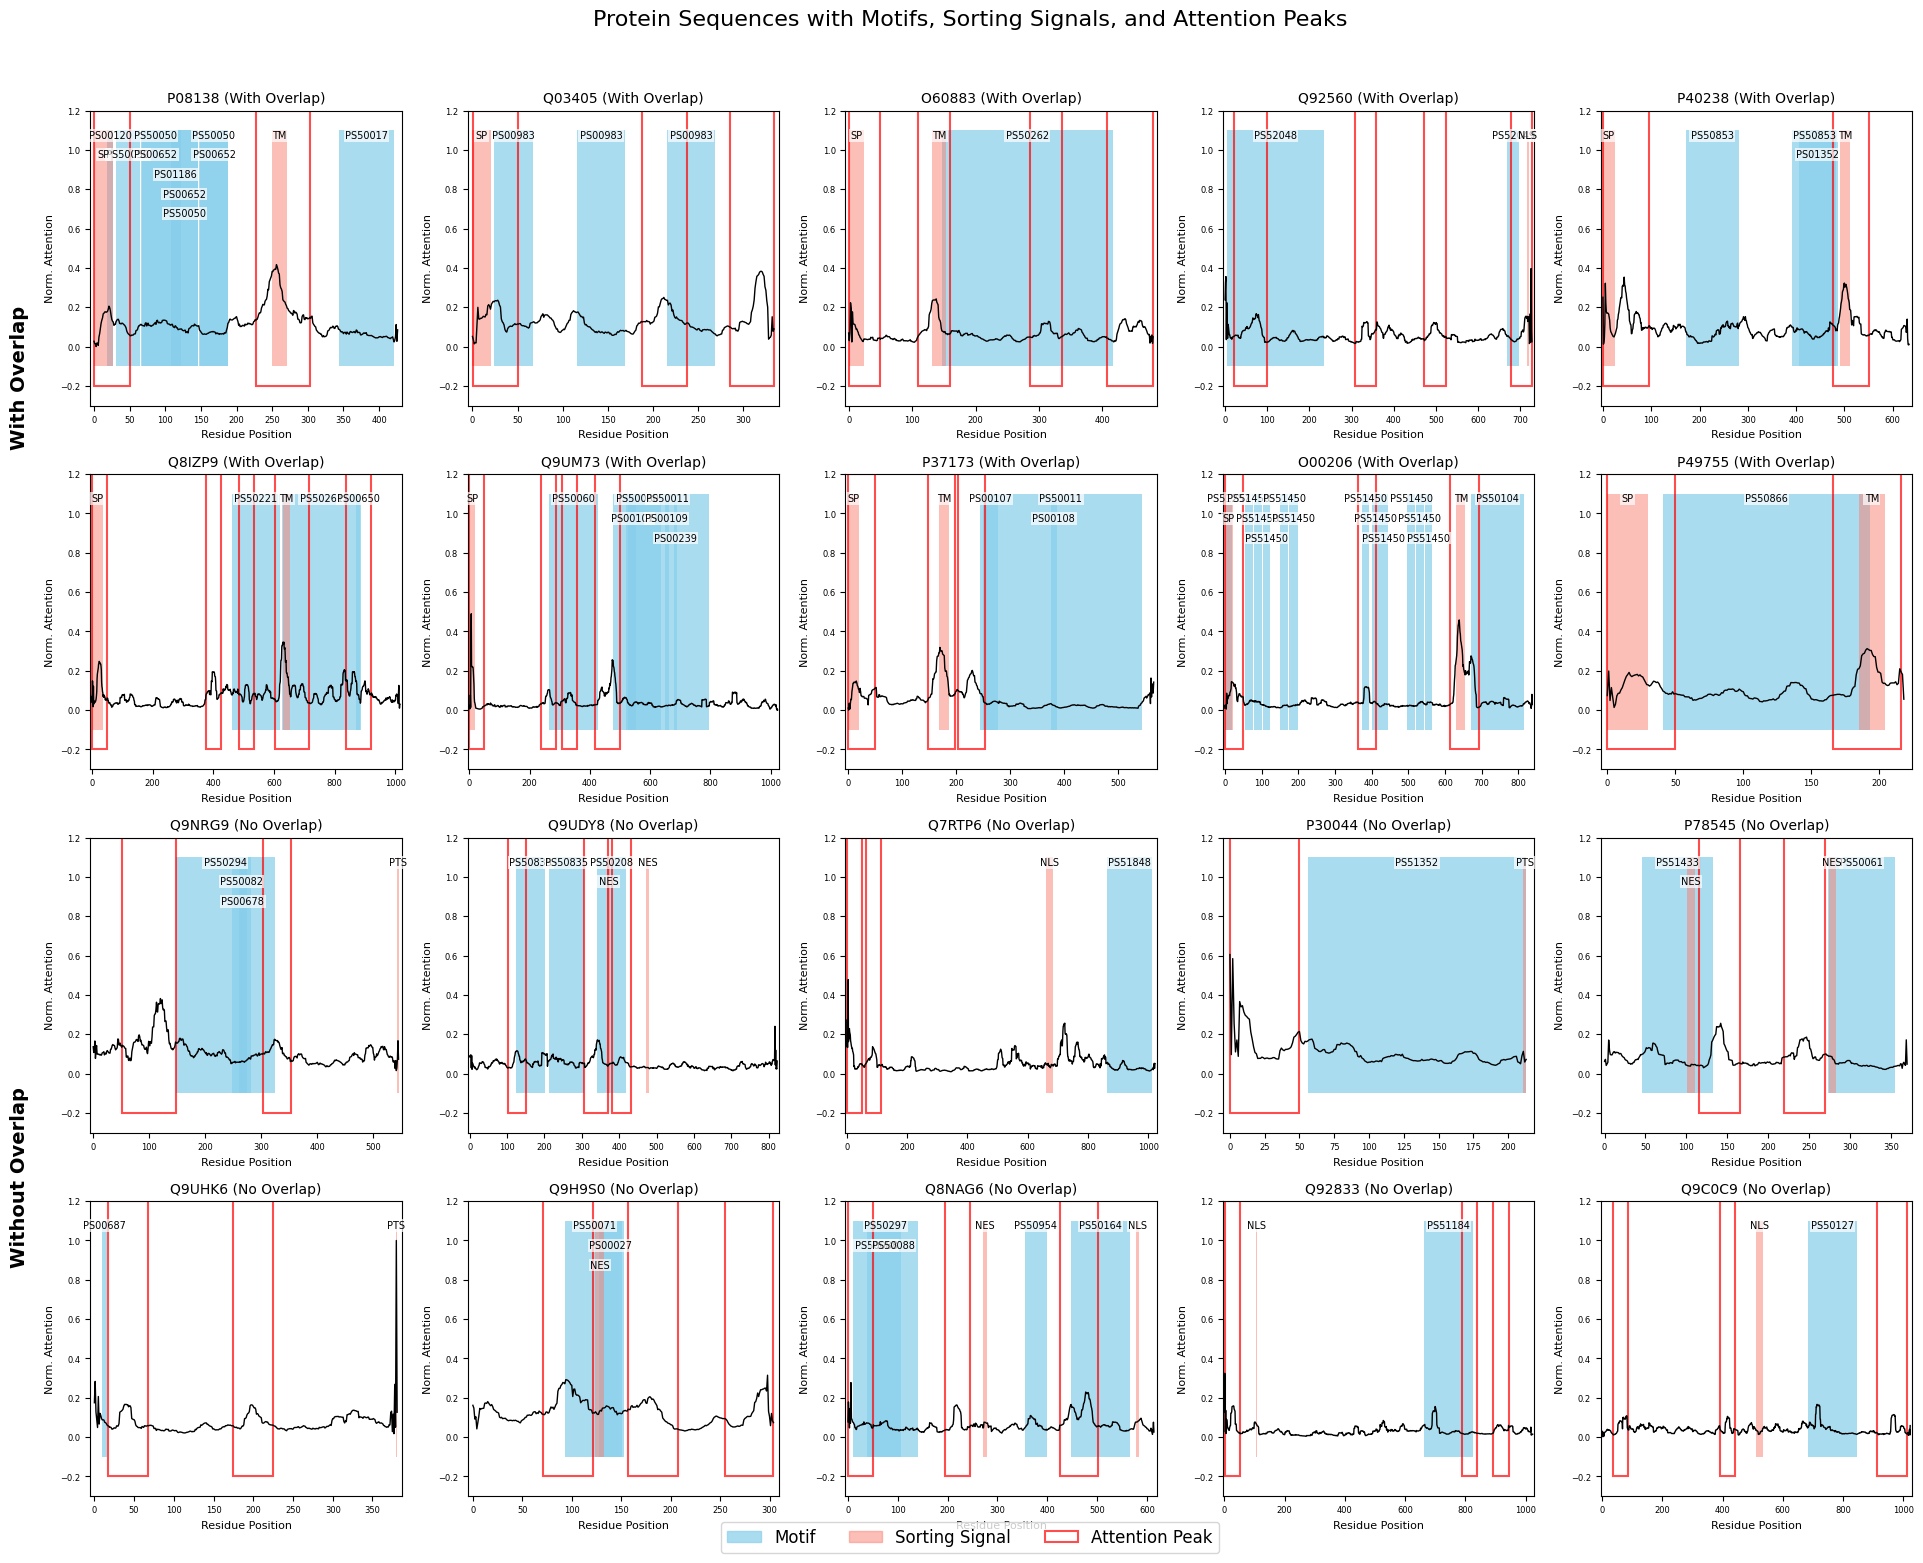

In [33]:
# Find proteins with both motifs and localization signals
proteins_with_both = set(corrected_prosite_motifs_df['protein_id']) & set(sorting_sigs_df['uniprot_id'])
print(f"Found {len(proteins_with_both)} proteins with both motifs and localization signals")

# Dictionary to store results
proteins_with_overlap = {}    # Proteins where at least one motif/signal overlaps with a peak
proteins_without_overlap = {} # Proteins where no motifs/signals overlap with any peak

# Process each protein
for protein_id in proteins_with_both:
    # Get motifs, signals, and peaks for this protein
    protein_motifs = corrected_prosite_motifs_df[corrected_prosite_motifs_df['protein_id'] == protein_id]
    protein_signals = sorting_sigs_df[sorting_sigs_df['uniprot_id'] == protein_id]
    protein_peaks = peaks_df[peaks_df['uniprot_id'] == protein_id]
    
    # Skip if no peaks found (need peaks to check overlap)
    if len(protein_peaks) == 0:
        continue
        
    # Track overlap status
    any_overlap = False
    
    # Check motif overlaps
    for _, motif in protein_motifs.iterrows():
        if check_overlap_with_peak(motif['corrected_start_pos'], motif['corrected_end_pos'], protein_peaks):
            any_overlap = True
            break
    
    # If no motifs overlap, check signal overlaps
    if not any_overlap:
        for _, signal in protein_signals.iterrows():
            if check_overlap_with_peak(signal['start_pos'], signal['end_pos'], protein_peaks):
                any_overlap = True
                break
    
    # Store protein information based on overlap status
    if any_overlap:
        proteins_with_overlap[protein_id] = {
            'motif_count': len(protein_motifs),
            'signal_count': len(protein_signals),
            'peak_count': len(protein_peaks)
        }
    else:
        proteins_without_overlap[protein_id] = {
            'motif_count': len(protein_motifs),
            'signal_count': len(protein_signals),
            'peak_count': len(protein_peaks)
        }

# Print results
print("\nProteins with at least one motif/signal overlapping with a peak:")
selected_with_overlap = list(proteins_with_overlap.keys())[:10]  # Increased to 10
for protein_id in selected_with_overlap:
    info = proteins_with_overlap[protein_id]
    print(f"{protein_id}: {info['motif_count']} motifs, {info['signal_count']} signals, {info['peak_count']} peaks")

print("\nProteins with no motifs/signals overlapping with any peak:")
selected_without_overlap = list(proteins_without_overlap.keys())[:10]  # Increased to 10
for protein_id in selected_without_overlap:
    info = proteins_without_overlap[protein_id]
    print(f"{protein_id}: {info['motif_count']} motifs, {info['signal_count']} signals, {info['peak_count']} peaks")

# Summary of selected proteins
print("\nSelected proteins with overlap:")
print(selected_with_overlap)
print("\nSelected proteins without overlap:")
print(selected_without_overlap)

# Main function to create the visualization with 10 proteins per category
def plot_proteins_with_features(proteins_with_overlap, proteins_without_overlap, 
                              hou_df, corrected_prosite_motifs_df, sorting_sigs_df, peaks_df, 
                              experiment_folder):
    """Create a figure with subplots for the selected proteins."""
    # Load attention data for all proteins
    print("Loading attention data...")
    attention_data = {}
    sequence_data = {}
    window_size = 15  # For smoothing attention values
    
    all_proteins = proteins_with_overlap + proteins_without_overlap
    
    for protein_id in all_proteins:
        smoothed_att, sequence = load_attention_data(
            experiment_folder, protein_id, hou_df, window_size=window_size
        )
        attention_data[protein_id] = smoothed_att
        sequence_data[protein_id] = sequence
    
    # Create figure with 4x5 grid (20 subplots total)
    fig = plt.figure(figsize=(20, 16))
    gs = gridspec.GridSpec(4, 5, figure=fig)
    
    # Plot proteins with overlap (top 2 rows)
    for i, protein_id in enumerate(proteins_with_overlap):
        row = i // 5
        col = i % 5
        ax = fig.add_subplot(gs[row, col])
        
        # Get protein data
        sequence = sequence_data[protein_id]
        protein_motifs = corrected_prosite_motifs_df[corrected_prosite_motifs_df['protein_id'] == protein_id]
        protein_signals = sorting_sigs_df[sorting_sigs_df['uniprot_id'] == protein_id]
        protein_peaks = peaks_df[peaks_df['uniprot_id'] == protein_id]
        
        # Plot the protein
        plot_protein_with_features(
            ax, protein_id, sequence, 
            protein_motifs, protein_signals, protein_peaks,
            attention_data[protein_id], has_overlap=True
        )
    
    # Plot proteins without overlap (bottom 2 rows)
    for i, protein_id in enumerate(proteins_without_overlap):
        row = (i // 5) + 2  # Start from row 2 (third row)
        col = i % 5
        ax = fig.add_subplot(gs[row, col])
        
        # Get protein data
        sequence = sequence_data[protein_id]
        protein_motifs = corrected_prosite_motifs_df[corrected_prosite_motifs_df['protein_id'] == protein_id]
        protein_signals = sorting_sigs_df[sorting_sigs_df['uniprot_id'] == protein_id]
        protein_peaks = peaks_df[peaks_df['uniprot_id'] == protein_id]
        
        # Plot the protein
        plot_protein_with_features(
            ax, protein_id, sequence, 
            protein_motifs, protein_signals, protein_peaks,
            attention_data[protein_id], has_overlap=False
        )
    
    # Create legend
    motif_patch = patches.Patch(color='skyblue', alpha=0.7, label='Motif')
    signal_patch = patches.Patch(color='salmon', alpha=0.5, label='Sorting Signal')
    peak_handle = patches.Rectangle((0, 0), 1, 1, linewidth=1.5, edgecolor='red', 
                                   facecolor='none', alpha=0.7, label='Attention Peak')
    
    fig.legend(
        handles=[motif_patch, signal_patch, peak_handle], 
        loc='lower center', 
        bbox_to_anchor=(0.5, 0.01),
        ncol=3,
        fontsize=12
    )
    
    # Add title
    fig.suptitle(
        f"Protein Sequences with Motifs, Sorting Signals, and Attention Peaks",
        fontsize=16, y=0.98
    )
    
    # Add row titles
    fig.text(0.02, 0.75, "With Overlap", fontsize=14, rotation=90, va='center', weight='bold')
    fig.text(0.02, 0.25, "Without Overlap", fontsize=14, rotation=90, va='center', weight='bold')
    
    # Adjust layout
    plt.tight_layout(rect=[0.03, 0.02, 0.98, 0.96])
    
    # Save and show figure
    output_file = f"{FIG_DIR}/protein_features_comparison_20proteins.svg"
    plt.savefig(output_file, format="svg", bbox_inches="tight")
    
    print(f"Visualization saved to: {output_file}")
    
    return fig


# Create the visualization with the updated protein lists
fig = plot_proteins_with_features(
    selected_with_overlap, 
    selected_without_overlap, 
    hou_df, 
    corrected_prosite_motifs_df, 
    sorting_sigs_df, 
    peaks_df, 
    PATH_TO_BEST_MODEL
)

# save figure as svg
fig.savefig(f"{FIG_DIR}/protein_features_comparison_20proteins.svg", format="svg", bbox_inches="tight")

Overall recall of localization signals: 0.76
Total signals: 260, Detected: 198

Recall by signal type:
GPI: 0.90 (9/10)
MT: 0.85 (17/20)
NES: 0.42 (13/31)
NLS: 0.64 (30/47)
PTS: 0.00 (0/3)
SP: 0.82 (75/91)
TM: 0.93 (54/58)

Visualizations saved to:
- Analysis/motif-analysis/motif_localization_analysis/localization_signal_recall.svg
- Analysis/motif-analysis/motif_localization_analysis/localization_signal_detected_undetected.svg


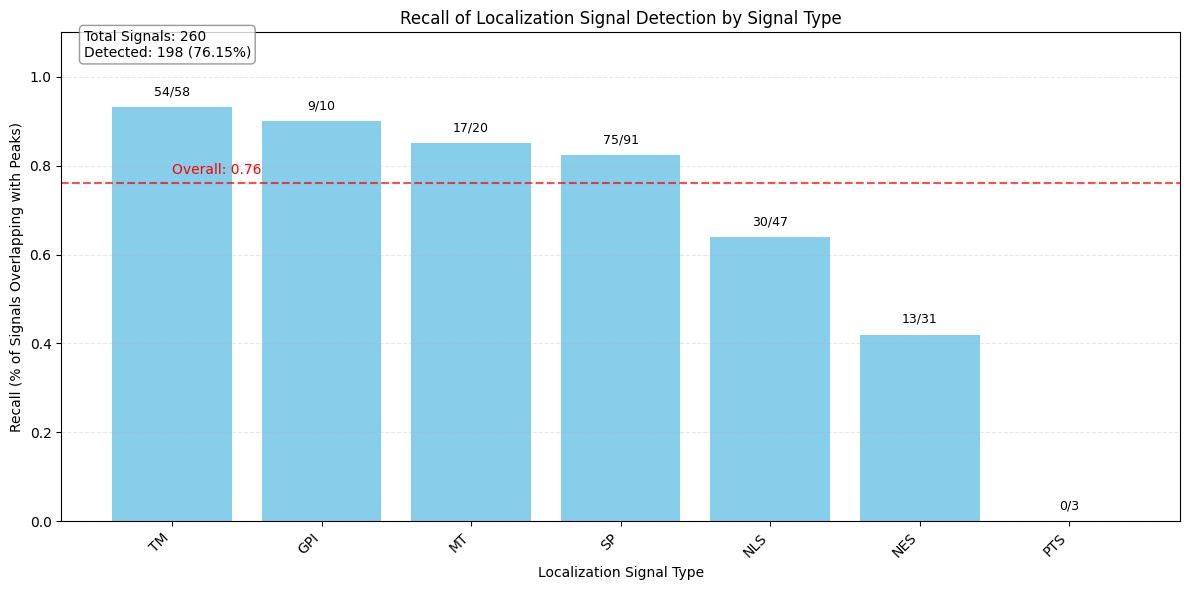

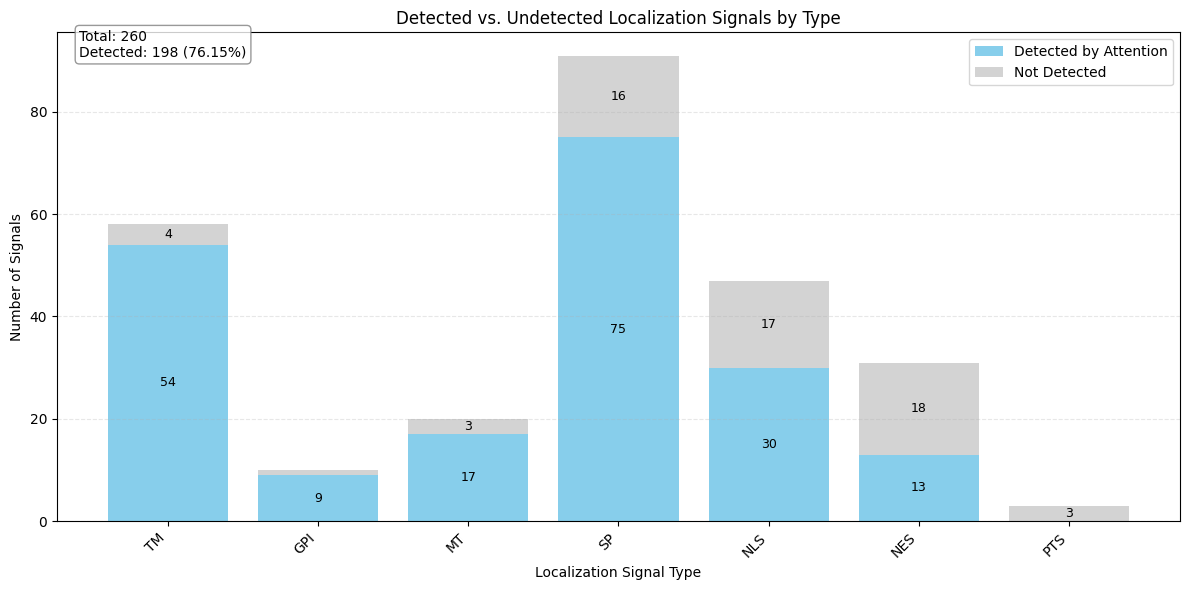

In [35]:
# compute recall of localization signals not stratified by protein localization class
# raw counts
# Calculate the recall of localization signals (detected by min 50% overlap with attention peak)
# across all proteins regardless of protein localization

# Function to check if a feature overlaps with any peak
def check_overlap_with_peak(start_pos, end_pos, protein_peaks, min_overlap_pct=0.5):
    for _, peak in protein_peaks.iterrows():
        peak_start = peak['start_pos']
        peak_end = peak['end_pos']
        if calculate_overlap_percentage((start_pos, end_pos), (peak_start, peak_end)) >= min_overlap_pct:
            return True
    return False

# Initialize counters for overall statistics
total_signals = 0
overlapping_signals = 0

# Initialize counters for signal-type specific statistics
signal_types = sorted(sorting_sigs_df['signal_type'].unique())
type_counts = {sig_type: 0 for sig_type in signal_types}
type_overlapping = {sig_type: 0 for sig_type in signal_types}

# Initialize list to store per-protein statistics
protein_stats = []

# Process each protein
for protein_id in sorted(set(sorting_sigs_df['uniprot_id'])):
    # Get signals and peaks for this protein
    protein_signals = sorting_sigs_df[sorting_sigs_df['uniprot_id'] == protein_id]
    protein_peaks = peaks_df[peaks_df['uniprot_id'] == protein_id]
    
    # Skip proteins with no signals or no peaks
    if len(protein_signals) == 0 or len(protein_peaks) == 0:
        continue
    
    # Track signals for this protein
    protein_total = len(protein_signals)
    protein_overlapping = 0
    protein_type_counts = {sig_type: 0 for sig_type in signal_types}
    protein_type_overlapping = {sig_type: 0 for sig_type in signal_types}
    
    # Check each signal for overlap with peaks
    for _, signal in protein_signals.iterrows():
        signal_type = signal['signal_type']
        start_pos = signal['start_pos']
        end_pos = signal['end_pos']
        
        # Update type counts
        type_counts[signal_type] += 1
        protein_type_counts[signal_type] += 1
        
        # Check if this signal overlaps with any peak
        if check_overlap_with_peak(start_pos, end_pos, protein_peaks):
            overlapping_signals += 1
            protein_overlapping += 1
            type_overlapping[signal_type] += 1
            protein_type_overlapping[signal_type] += 1
    
    # Update total count
    total_signals += protein_total
    
    # Store protein-level statistics
    protein_recall = protein_overlapping / protein_total if protein_total > 0 else 0
    protein_stats.append({
        'protein_id': protein_id,
        'total_signals': protein_total,
        'overlapping_signals': protein_overlapping,
        'recall': protein_recall,
        'signal_types': protein_type_counts,
        'overlapping_by_type': protein_type_overlapping
    })

# Calculate overall recall
overall_recall = overlapping_signals / total_signals if total_signals > 0 else 0
print(f"Overall recall of localization signals: {overall_recall:.2f}")
print(f"Total signals: {total_signals}, Detected: {overlapping_signals}")

# Calculate recall by signal type
type_recall = {sig_type: type_overlapping[sig_type] / type_counts[sig_type] 
               if type_counts[sig_type] > 0 else 0 
               for sig_type in signal_types}

print("\nRecall by signal type:")
for sig_type in signal_types:
    print(f"{sig_type}: {type_recall[sig_type]:.2f} ({type_overlapping[sig_type]}/{type_counts[sig_type]})")

# Create dataframe for visualization
recall_data = pd.DataFrame({
    'Signal Type': signal_types,
    'Total': [type_counts[sig_type] for sig_type in signal_types],
    'Overlapping': [type_overlapping[sig_type] for sig_type in signal_types],
    'Recall': [type_recall[sig_type] for sig_type in signal_types]
})

# Sort by recall (descending)
recall_data = recall_data.sort_values('Recall', ascending=False)

# Create bar plot of recall by signal type
plt.figure(figsize=(12, 6))

# Plot bars
bars = plt.bar(recall_data['Signal Type'], recall_data['Recall'], color='skyblue')

# Add count labels on top of each bar
for i, bar in enumerate(bars):
    total = recall_data.iloc[i]['Total']
    overlapping = recall_data.iloc[i]['Overlapping']
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{overlapping}/{total}", 
            ha='center', va='bottom', fontsize=9)

# Add horizontal line at overall recall
plt.axhline(y=overall_recall, color='red', linestyle='--', alpha=0.7)
plt.text(0, overall_recall + 0.02, f"Overall: {overall_recall:.2f}", color='red', ha='left')

plt.xlabel('Localization Signal Type')
plt.ylabel('Recall (% of Signals Overlapping with Peaks)')
plt.title('Recall of Localization Signal Detection by Signal Type')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)  # Set y-axis to go from 0 to 1.1 to make room for labels
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add annotations
total_count_text = f"Total Signals: {total_signals}\nDetected: {overlapping_signals} ({overall_recall:.2%})"
plt.annotate(total_count_text, xy=(0.02, 0.95), xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/localization_signal_recall.svg", format="svg")

# Create a second visualization: Stacked bar chart showing detected vs. undetected
plt.figure(figsize=(12, 6))

# Extract data for plotting
signal_types = recall_data['Signal Type']
detected = recall_data['Overlapping']
undetected = recall_data['Total'] - recall_data['Overlapping']

# Create stacked bars
plt.bar(signal_types, detected, label='Detected by Attention', color='skyblue')
plt.bar(signal_types, undetected, bottom=detected, label='Not Detected', color='lightgray')

# Add count labels inside each segment
for i, (d, u) in enumerate(zip(detected, undetected)):
    # Only add text if segment is large enough
    if d > 1:
        plt.text(i, d/2, str(int(d)), ha='center', va='center', color='black', fontsize=9)
    if u > 1:
        plt.text(i, d + u/2, str(int(u)), ha='center', va='center', color='black', fontsize=9)

plt.xlabel('Localization Signal Type')
plt.ylabel('Number of Signals')
plt.title('Detected vs. Undetected Localization Signals by Type')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add annotation for total numbers
plt.annotate(f"Total: {total_signals}\nDetected: {overlapping_signals} ({overall_recall:.2%})",
            xy=(0.02, 0.95), xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/localization_signal_detected_undetected.svg", format="svg")

print("\nVisualizations saved to:")
print("- Analysis/motif-analysis/motif_localization_analysis/localization_signal_recall.svg")
print("- Analysis/motif-analysis/motif_localization_analysis/localization_signal_detected_undetected.svg")

In [36]:
# Calculate global statistics for sorting signals and motifs - constrained to relevant protein subsets

# 1. For sorting signals (only considering proteins that have sorting signals)
proteins_with_signals = sorting_sigs_df['uniprot_id'].nunique()
total_signals = len(sorting_sigs_df)
avg_signals_per_protein = total_signals / proteins_with_signals

# Get all attention peaks
all_peaks = []
for _, row in peaks_df.iterrows():
    peak = (row['uniprot_id'], row['start_pos'], row['end_pos'])
    all_peaks.append(peak)

# Count peaks that overlap with sorting signals (only for proteins that have signals)
signal_proteins = set(sorting_sigs_df['uniprot_id'])
peaks_with_signal_overlap = set()
peaks_in_proteins_with_signals = set()

for _, peak_row in peaks_df.iterrows():
    protein_id = peak_row['uniprot_id']
    peak_key = (protein_id, peak_row['start_pos'], peak_row['end_pos'])
    
    # Only consider proteins that have signals
    if protein_id in signal_proteins:
        peaks_in_proteins_with_signals.add(peak_key)

# Check for overlaps
for _, signal in sorting_sigs_df.iterrows():
    protein_id = signal['uniprot_id']
    signal_start = signal['start_pos']
    signal_end = signal['end_pos']
    
    protein_peaks = peaks_df[peaks_df['uniprot_id'] == protein_id]
    for _, peak in protein_peaks.iterrows():
        peak_key = (protein_id, peak['start_pos'], peak['end_pos'])
        if calculate_overlap_percentage((signal_start, signal_end), (peak['start_pos'], peak['end_pos'])) >= 0.5:
            peaks_with_signal_overlap.add(peak_key)

# Calculate percentage of peaks in signal-containing proteins that overlap with signals
pct_peaks_with_signal_overlap = (len(peaks_with_signal_overlap) / len(peaks_in_proteins_with_signals) * 100 
                                if peaks_in_proteins_with_signals else 0)

# 2. For ProSite motifs (only considering proteins that have motifs)
proteins_with_motifs = corrected_prosite_motifs_df['protein_id'].nunique()
total_motifs = len(corrected_prosite_motifs_df)
avg_motifs_per_protein = total_motifs / proteins_with_motifs

# Count peaks that overlap with ProSite motifs (only for proteins that have motifs)
motif_proteins = set(corrected_prosite_motifs_df['protein_id'])
peaks_with_motif_overlap = set()
peaks_in_proteins_with_motifs = set()

for _, peak_row in peaks_df.iterrows():
    protein_id = peak_row['uniprot_id']
    peak_key = (protein_id, peak_row['start_pos'], peak_row['end_pos'])
    
    # Only consider proteins that have motifs
    if protein_id in motif_proteins:
        peaks_in_proteins_with_motifs.add(peak_key)

# Check for overlaps
for _, motif in corrected_prosite_motifs_df.iterrows():
    protein_id = motif['protein_id']
    motif_start = motif['corrected_start_pos']
    motif_end = motif['corrected_end_pos']
    
    protein_peaks = peaks_df[peaks_df['uniprot_id'] == protein_id]
    for _, peak in protein_peaks.iterrows():
        peak_key = (protein_id, peak['start_pos'], peak['end_pos'])
        if calculate_overlap_percentage((motif_start, motif_end), (peak['start_pos'], peak['end_pos'])) >= 0.5:
            peaks_with_motif_overlap.add(peak_key)

# Calculate percentage of peaks in motif-containing proteins that overlap with motifs
pct_peaks_with_motif_overlap = (len(peaks_with_motif_overlap) / len(peaks_in_proteins_with_motifs) * 100 
                               if peaks_in_proteins_with_motifs else 0)

# Print the results
print("\nGlobal Statistics (constrained to relevant protein subsets):")
print(f"1. Sorting Signals:")
print(f"   Total proteins with sorting signals: {proteins_with_signals}")
print(f"   Average sorting signals per protein with signals: {avg_signals_per_protein:.2f}")
print(f"   Percentage of attention peaks overlapping with sorting signals: {pct_peaks_with_signal_overlap:.2f}%")
print(f"   (Based on {len(peaks_in_proteins_with_signals)} peaks in proteins with signals)")
print(f"2. ProSite Motifs:")
print(f"   Total proteins with ProSite motifs: {proteins_with_motifs}")
print(f"   Average ProSite motifs per protein with motifs: {avg_motifs_per_protein:.2f}")
print(f"   Percentage of attention peaks overlapping with ProSite motifs: {pct_peaks_with_motif_overlap:.2f}%")
print(f"   (Based on {len(peaks_in_proteins_with_motifs)} peaks in proteins with motifs)")


Global Statistics (constrained to relevant protein subsets):
1. Sorting Signals:
   Total proteins with sorting signals: 184
   Average sorting signals per protein with signals: 1.42
   Percentage of attention peaks overlapping with sorting signals: 47.10%
   (Based on 414 peaks in proteins with signals)
2. ProSite Motifs:
   Total proteins with ProSite motifs: 2353
   Average ProSite motifs per protein with motifs: 2.87
   Percentage of attention peaks overlapping with ProSite motifs: 18.48%
   (Based on 5914 peaks in proteins with motifs)
